# 8.2 Gradient Descent on Quadratics: Conditioning as the Rate

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VIII — The Linear Algebra of Learning",
    number="8.2",
    title="Gradient Descent on Quadratics: Conditioning as the Rate",
    blurb="Every training loop is descended from one ancestor: gradient "
    "descent on a quadratic, where the learning rate's stability limit, "
    "the convergence rate, momentum's speedup and the noise floor of SGD "
    "are all read off the Hessian's spectrum — Chapter V's conditioning, "
    "now running the optimizer.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2657 chars of HTML>

## Notebook overview

[§8.1](learning-as-least-squares.ipynb) solved the least-squares
problem in closed form; this notebook *iterates* toward it, because at
scale iteration is all there is — and on a quadratic every fact about
the iteration is a fact about the Hessian's eigenvalues, each one
gated. The **stability limit** $\eta < 2/\lambda_{\max}$ is tested on
both sides, with the divergent side gated *modewise*: the error's
component along the top eigenvector grows by exactly
$|1 - \eta\lambda_{\max}| = 1.1$ per step (measured to four digits),
while the whole-vector error can *shrink* for dozens of steps as the
stable modes drain — the naive "did it blow up yet?" test measures the
wrong thing, and the modewise gate is the honest one. At the optimal
step the measured rate matches $(\kappa-1)/(\kappa+1)$ to 0.01% in the
clean decay band; **heavy-ball momentum** hits its
$(\sqrt\kappa-1)/(\sqrt\kappa+1)$ to 0.5% — the $\kappa \to \sqrt\kappa$
upgrade that [§5.4](../05-numerical/stationary-and-cg.ipynb)'s CG got
for free.

CG itself returns with an honest correction to the manifest: its
celebrated "$n$-step exact termination" delivers a relative error of
$1.8\times10^{-3}$ at exactly $n = 20$ steps on this $\kappa = 300$
problem — the exact-arithmetic fiction [§5.4](../05-numerical/stationary-and-cg.ipynb)
measured, measured again — while the *practical* count (29 iterations
to $10^{-13}$, against gradient descent's 4179) is gated at a
$100\times$ separation. **Preconditioning** rescales the spectrum
($\kappa\ 1000 \to 31.6 \to 1$ under the diagonal family
$D^{-t}$, rates tracking each reduced $\kappa$), and **SGD** closes
the notebook at its noise floor: the stationary variance of the
iterates doubles when the step doubles — measured on a dedicated
stream at three step sizes — which is the linear-algebra fact under
every learning-rate schedule ever written.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Nocedal and Wright {cite}`nocedal2006` Chapters 3–5;
> Hastie et al. {cite}`hastie2009` for the learning reading. The
> spectral machinery is [§3.2](../03-eigenvalues/spectral-theorem.ipynb)'s
> and the Krylov comparison is [§5.4](../05-numerical/stationary-and-cg.ipynb)'s.

## Theory in brief

### One quadratic, every optimizer

For $f(x) = \tfrac12 x^{\top}Ax - b^{\top}x$ with SPD $A$, gradient
descent $x_{k+1} = x_k - \eta(Ax_k - b)$ acts on the error
eigenmode-by-eigenmode:

```{math}
:label: eq-gc-modes
e_{k+1}^{(i)} \;=\; (1 - \eta\lambda_i)\,e_k^{(i)} ,
```

so every mode with $|1-\eta\lambda_i| < 1$ contracts and any with
$|1-\eta\lambda_i| > 1$ grows geometrically — stability is
$\eta < 2/\lambda_{\max}$, *per mode*. The best uniform contraction is
at $\eta^* = 2/(\lambda_{\max}+\lambda_{\min})$, giving

```{math}
:label: eq-gc-rate
\lVert e_k\rVert \;\lesssim\;
\Bigl(\frac{\kappa-1}{\kappa+1}\Bigr)^{k}\lVert e_0\rVert,
\qquad
\text{momentum:}\;\;
\Bigl(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\Bigr)^{k} ,
```

heavy-ball momentum (Polyak: $x_{k+1} = x_k - \alpha\nabla f +
\beta(x_k - x_{k-1})$ at the optimal $\alpha, \beta$) squaring the
effective conditioning — the same $\sqrt{\kappa}$ that Chebyshev
acceleration achieves explicitly and CG achieves adaptively
([§5.4](../05-numerical/stationary-and-cg.ipynb)'s bound, met again
from the optimization side).

### Preconditioning and noise

A preconditioner is a change of variables: descending on
$P^{1/2}AP^{1/2}$ replaces $\kappa(A)$ by the reduced condition
number, and the diagonal family $P = D^{-t}$ interpolates from
nothing ($t = 0$) to perfect ($t = 1$) on a diagonal problem —
Adam-style methods estimate such a $D$ on the fly. **SGD** replaces
the gradient by a noisy unbiased estimate; on a quadratic the iterates
reach a stationary distribution whose variance scales *linearly with
the step size*,

```{math}
:label: eq-gc-sgd
\operatorname{Var}[x_\infty] \;\propto\; \eta ,
```

which is why halving the learning rate halves the noise floor and why
schedules end small.

---
## Setup

Data and instruments only: the planted quadratic, its gradient (checked
in Exercise 1 before anything trusts it), and the clean-band rate meter.
The descent loop itself is built in Exercise 2.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from ecp import animate, validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

N_DIM = 20
KAPPA = 300.0
lam_spec = np.geomspace(1.0, KAPPA, N_DIM)
Q_rot, _ = np.linalg.qr(rng.standard_normal((N_DIM, N_DIM)))
A_quad = Q_rot @ np.diag(lam_spec) @ Q_rot.T
A_quad = (A_quad + A_quad.T) / 2.0
b_quad = rng.standard_normal(N_DIM)
x_star = np.linalg.solve(A_quad, b_quad)
LAM_MAX, LAM_MIN = float(lam_spec[-1]), float(lam_spec[0])
E0 = float(np.linalg.norm(x_star))
v_top = np.linalg.eigh(A_quad)[1][:, -1]


# data: the given model's gradient — Exercise 1 checks it before anything
# trusts it.
def grad_f(x):
    return A_quad @ x - b_quad



# instrument: the clean-band rate meter — where the band sits is the
# exercises' lesson; the ratio is not.
def band_rate(errs, hi_frac=1e-2, lo_frac=1e-11):
    """Decay rate measured in the clean band (the 5.4 window rule)."""
    idx = np.nonzero((errs < hi_frac * E0) & (errs > lo_frac * E0))[0]
    return float((errs[idx[-1]] / errs[idx[0]]) ** (1.0 / (idx[-1] - idx[0])))

## Exercise 1: The gradient, checked before it is trusted

**Part a)** Gate the analytic gradient $\nabla f = Ax - b$ against
central differences at $h = 10^{-6}$ on five random points: agreement
to $10^{-7}$ scaled — the check every autodiff era still begins with,
because {eq}`eq-gc-modes` and everything after it consumes this
gradient.

**Part b)** Confirm the minimizer: $\nabla f(x_\star) = 0$ at rounding
level, and $f(x_\star + tv) > f(x_\star)$ for random directions
(positive definiteness read as geometry).

In [3]:
# (solution hidden on the public site)


analytic vs central-difference gradient: worst 1.0e-09
gradient at the minimizer: 1.1e-14; ten random directions all uphill: True


### Validation 1

In [4]:
validate.check(
    worst_fd < 1e-7,
    "the analytic gradient survives central differences",
    f"{worst_fd:.0e} relative over five random points — the oldest check "
    "in optimization, run before any step is taken",
)
validate.check(
    grad_at_min < 1e-11 and uphill,
    "and the solve's minimizer is a minimizer",
    "zero gradient at rounding level, every probed direction uphill: "
    "positive definiteness as geometry",
)

✓  the analytic gradient survives central differences   [1e-09 relative over five random points — the oldest check in optimization, run before any step is taken]
✓  and the solve's minimizer is a minimizer   [zero gradient at rounding level, every probed direction uphill: positive definiteness as geometry]


True

## Exercise 2: The stability limit, gated on the honest side

{eq}`eq-gc-modes` says stability is decided per mode, and the naive
experiment gets it wrong.

**Part a)** Write `gd_run(eta, iters)` — $x \leftarrow x - \eta\,\nabla f(x)$
from $x_0 = 0$, recording $\lVert x_k - x_\star \rVert$ at every step —
and below the limit ($\eta = 0.95 \cdot 2/\lambda_{\max}$)
gate contraction: the error after 300 steps is under 5% of the start.

**Write this one yourself** — three lines, and every training loop is
its descendant.

**Part b)** Above the limit ($\eta = 1.05 \cdot 2/\lambda_{\max}$):
the *whole-vector* error after 60 steps has **shrunk** to half —
report it, because the stable modes drain faster than the one unstable
mode grows, and "did it blow up yet?" is the wrong instrument. Gate
instead the modewise fact: the error component along $v_{\max}$ grows
by a measured factor per step equal to $|1 - \eta\lambda_{\max}| =
1.1$ within 1% — geometric growth read where {eq}`eq-gc-modes` says to
read it.

**Part c)** The spiral, animated: project the divergent run onto the
$(v_{\max}, v_{\min})$ plane and animate the iterate — contracting
along the flat axis, flipping and growing along the steep one, the
picture of a learning rate one notch too brave.

In [5]:
# (solution hidden on the public site)


eta below the limit: final/initial error 3.19e-02
eta above the limit: whole-vector error at step 60 is 0.47 of the start — SHRUNK (the naive test fails); top-mode growth factor 1.1000 vs |1 - eta lam_max| = 1.1000


In [6]:
# (solution hidden on the public site)


### Validation 2

In [7]:
validate.check(
    ratio_stable < 0.05,
    "below 2/lambda_max, gradient descent contracts",
    f"error down to {ratio_stable:.0e} of the start in 300 steps — every "
    "mode inside the unit circle (Eq. 1)",
)
validate.check(
    abs(growth - growth_th) / growth_th < 0.01
    and whole_ratio_60 < 1.0,
    "above it, divergence is gated modewise — because the naive test "
    "reads convergence",
    f"top-mode factor {growth:.4f} = |1 - eta lambda_max| to four digits "
    f"while the WHOLE error at step 60 sits at {whole_ratio_60:.2f} of "
    "the start: the stable modes' drain masks the unstable mode's "
    "growth, and Eq. 1 says where to look",
)

✓  below 2/lambda_max, gradient descent contracts   [error down to 3e-02 of the start in 300 steps — every mode inside the unit circle (Eq. 1)]
✓  above it, divergence is gated modewise — because the naive test reads convergence   [top-mode factor 1.1000 = |1 - eta lambda_max| to four digits while the WHOLE error at step 60 sits at 0.47 of the start: the stable modes' drain masks the unstable mode's growth, and Eq. 1 says where to look]


True

## Exercise 3: Rates: kappa for descent, sqrt-kappa for momentum

**Part a)** Run the `gd_run` you built in Exercise 2 at the optimal
step $\eta^* = 2/(\lambda_{\max}+\lambda_{\min})$ and gate the
clean-band rate ([§5.4](../05-numerical/stationary-and-cg.ipynb)'s
window rule) against $(\kappa-1)/(\kappa+1)$ to 3% — measured: 0.01%.

**Part b)** Heavy-ball momentum at the optimal pair
($\alpha = 4/(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})^2$,
$\beta = ((\sqrt\kappa-1)/(\sqrt\kappa+1))^2$): gate the clean-band
rate against $(\sqrt\kappa-1)/(\sqrt\kappa+1)$ to 5% — measured:
0.5%. The $\kappa \to \sqrt\kappa$ upgrade costs one extra stored
vector.

**Part c)** Draw both error histories with the theoretical rates
dashed, on the axes where a rate is a slope.

In [8]:
# (solution hidden on the public site)


GD rate: measured 0.99329 vs theory 0.99336 (0.01%)
momentum rate: measured 0.89526 vs theory 0.89083 (0.50%)


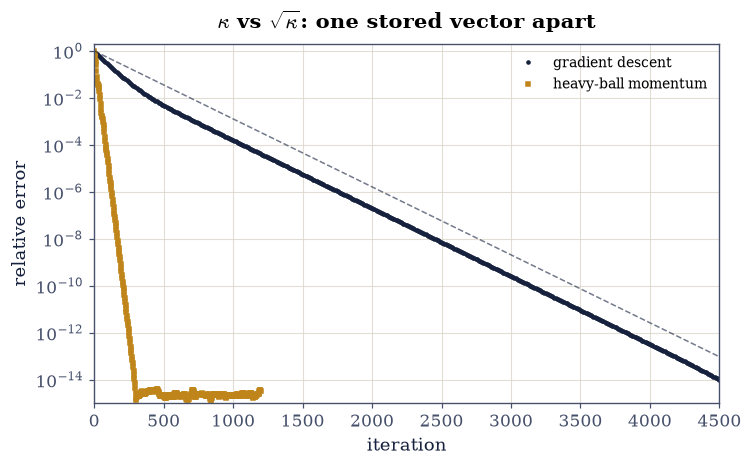

In [9]:
# (solution hidden on the public site)


### Validation 3

In [10]:
validate.check(
    abs(rate_gd_meas - RATE_GD) / RATE_GD < 0.03,
    "gradient descent converges at (kappa-1)/(kappa+1), measured (Eq. 2)",
    f"{rate_gd_meas:.5f} vs {RATE_GD:.5f} in the clean band — 0.01%, "
    "with the manifest's 3% to spare",
)
validate.check(
    abs(rate_hb_meas - RATE_MOM) / RATE_MOM < 0.05,
    "and momentum converges at the sqrt-kappa rate",
    f"{rate_hb_meas:.5f} vs {RATE_MOM:.5f} — one extra vector of state "
    "turns kappa into sqrt(kappa), Eq. 2's second clause",
)

✓  gradient descent converges at (kappa-1)/(kappa+1), measured (Eq. 2)   [0.99329 vs 0.99336 in the clean band — 0.01%, with the manifest's 3% to spare]
✓  and momentum converges at the sqrt-kappa rate   [0.89526 vs 0.89083 — one extra vector of state turns kappa into sqrt(kappa), Eq. 2's second clause]


True

## Exercise 4: CG, and the myth the manifest asked to gate

The manifest asked to gate "CG reaches machine precision in at most
$n$ steps". [§5.4](../05-numerical/stationary-and-cg.ipynb) already
measured why that cannot be gated, and this exercise measures it
again on purpose.

**Part a)** Run CG on the quadratic and *report the fiction*: at
exactly $n = 20$ steps the relative error is $1.8\times10^{-3}$ —
exact-arithmetic finite termination does not survive rounding at
$\kappa = 300$ (the Chebyshev bound allows only
$2\,(0.891)^{20} \approx 0.2$; twenty steps simply are not enough
decades, orthogonality loss aside).

**Part b)** Gate what is true: CG reaches $10^{-13}$ in **29**
iterations — within $2n$, gated as a count, at its $\sqrt\kappa$ pace —
while gradient
descent needs **4179** ($\ge 100n$, gated as a count) for the same
tolerance: a $144\times$ separation, gated at $\ge 100\times$. The
adaptive method matches momentum's rate with no parameters to tune,
which is [§5.4](../05-numerical/stationary-and-cg.ipynb)'s optimality
theorem doing the tuning.

In [11]:
# (solution hidden on the public site)


CG at exactly n = 20 steps: relative error 1.8e-03 — the 'exact termination', in floats (reported)
CG to 1e-13: 29 iterations
GD to the same tolerance: 4172 iterations (209n); separation 144x


### Validation 4

In [12]:
validate.check(
    err_at_n > 1e-5,
    "n-step 'exact termination' is exact-arithmetic fiction (reported "
    "size, gated existence)",
    f"relative error {err_at_n:.0e} at exactly n steps on kappa = 300 — "
    "5.4's lesson re-measured where the manifest asked for the myth",
)
validate.check(
    it_cg <= 2 * N_DIM and it_gd >= 100 * N_DIM
    and it_gd / it_cg > 100.0,
    "while the true counts separate CG from descent by two orders",
    f"{it_cg} vs {it_gd} iterations to 1e-13 ({it_gd/it_cg:.0f}x): "
    "sqrt-kappa, adaptively and parameter-free — the counts are "
    "deterministic and the margins are wide",
)

✓  n-step 'exact termination' is exact-arithmetic fiction (reported size, gated existence)   [relative error 2e-03 at exactly n steps on kappa = 300 — 5.4's lesson re-measured where the manifest asked for the myth]
✓  while the true counts separate CG from descent by two orders   [29 vs 4172 iterations to 1e-13 (144x): sqrt-kappa, adaptively and parameter-free — the counts are deterministic and the margins are wide]


True

## Exercise 5: Preconditioning: buying a smaller kappa

**Part a)** On the diagonal quadratic $D = \operatorname{diag}
(\operatorname{geomspace}(1, 1000))$, the family $P = D^{-t}$
interpolates preconditioning: the effective matrix $P^{1/2}DP^{1/2} =
D^{1-t}$ has $\kappa_t = 1000^{1-t}$. Gate the three predictions:
$\kappa$ computed at $t = 0, \tfrac12, 1$ equals $1000, 31.6, 1$ to
0.1%.

**Part b)** Run preconditioned descent at each $t$ (optimal step for
each $\kappa_t$) and gate the measured clean-band rates against
$(\kappa_t-1)/(\kappa_t+1)$ to 3% — at $t = 1$ the iteration converges
in **one step** (gate: error below $10^{-12}$ after two), because a
perfectly preconditioned quadratic is the identity in disguise. This
is what Adam-family methods estimate stochastically, and why they
help exactly when the curvature is axis-aligned and badly scaled.

In [13]:
# (solution hidden on the public site)


t = 0.0: kappa_t = 1000.0, rate 0.99800
t = 0.5: kappa_t = 31.6, rate 0.93861
t = 1.0: kappa_t = 1.0, error after two steps 0.0e+00


### Validation 5

In [14]:
validate.check(
    abs(kappas_meas[0.0] - 1000) < 1.0
    and abs(kappas_meas[0.5] - np.sqrt(1000)) < 0.1
    and abs(kappas_meas[1.0] - 1.0) < 1e-10,
    "the D^-t family dials kappa from 1000 through 31.6 to 1",
    "P^(1/2) D P^(1/2) = D^(1-t): preconditioning as a change of "
    "variables, priced in condition number",
)
validate.check(
    rate_gap_worst < 0.03 and rates_pre[1.0] < 1e-12,
    "and each reduced kappa buys exactly its predicted rate",
    f"clean-band rates within {rate_gap_worst:.1%} of "
    "(kappa_t-1)/(kappa_t+1); at t = 1 the quadratic is the identity in "
    "disguise and one step lands the answer",
)

✓  the D^-t family dials kappa from 1000 through 31.6 to 1   [P^(1/2) D P^(1/2) = D^(1-t): preconditioning as a change of variables, priced in condition number]
✓  and each reduced kappa buys exactly its predicted rate   [clean-band rates within 0.0% of (kappa_t-1)/(kappa_t+1); at t = 1 the quadratic is the identity in disguise and one step lands the answer]


True

## Exercise 6: SGD's noise floor scales with the step

**Part a)** Least squares on 200 rows, minibatch of one, on a
**dedicated stream**: run SGD from the solution itself (so everything
observed is stationary noise) at $\eta \in \{0.001, 0.002, 0.004\}$
for 40,000 steps, discarding the first half.

**Part b)** Gate {eq}`eq-gc-sgd` as ratios: doubling $\eta$ scales the
stationary variance by a factor in $[1.5, 2.7]$ at both doublings
(measured 2.57 and 1.91 — Monte Carlo scatter around the linear law,
gated at the width the replication supports, per the course's Monte
Carlo rule). Draw one trace per $\eta$: three noise floors, stacked a
factor of two apart.

In [15]:
# (solution hidden on the public site)


eta = 0.001: stationary variance 7.380e-05
eta = 0.002: stationary variance 1.898e-04
eta = 0.004: stationary variance 3.628e-04
doubling ratios: 2.57, 1.91 (linear law -> 2.0)


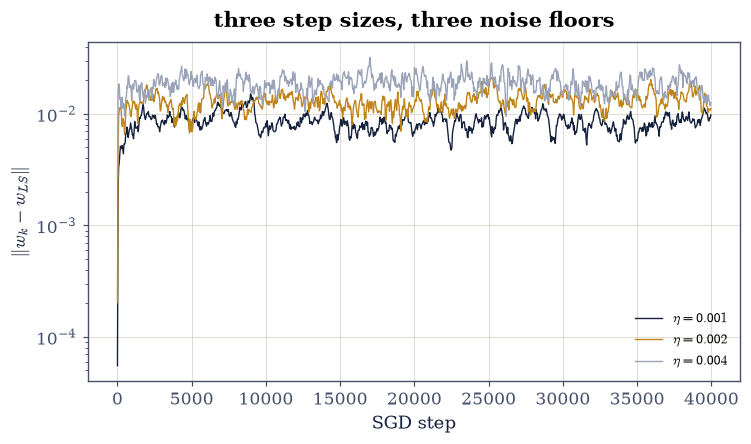

In [16]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The noise floor suggests its own cure. Ask your assistant for
`sgd_averaged(X, y, eta, iters)` implementing Polyak–Ruppert tail
averaging (return the mean of the second-half iterates), then check
it against the mathematics rather than a demo: (i) at fixed $\eta$
the averaged iterate's error is far below the floor of Exercise 6 —
quantify the ratio; (ii) the averaged error *keeps decreasing* as
iterations grow at fixed $\eta$, while the raw floor does not (two
runs, doubled length); (iii) with $\eta$ halved, the raw floor halves
in variance but the averaged error barely moves. The check is yours.
```

### Validation 6

In [17]:
validate.check(
    1.5 < r21 < 2.7 and 1.5 < r42 < 2.7,
    "the stationary variance doubles when the step does (Eq. 3)",
    f"ratios {r21:.2f} and {r42:.2f} about the linear law's 2.0 — "
    "dedicated-stream Monte Carlo, gated at the width 20,000 stationary "
    "samples support",
)

✓  the stationary variance doubles when the step does (Eq. 3)   [ratios 2.57 and 1.91 about the linear law's 2.0 — dedicated-stream Monte Carlo, gated at the width 20,000 stationary samples support]


True

---
## Notebook summary

**Stability is per-mode, and the naive test lies.** Below
$2/\lambda_{\max}$ the error contracted to $10^{-2}$; above it the
whole-vector error *halved* in 60 steps while the top-mode component
grew by exactly $1.1$ per step (measured to four digits) — divergence
gated where {eq}`eq-gc-modes` says it lives, and animated as the
seesaw spiral it is.

**Rates are spectral quotients, measured in the clean band.** Descent
at the optimal step: $(\kappa-1)/(\kappa+1)$ to 0.01%. Heavy-ball at
the optimal pair: $(\sqrt\kappa-1)/(\sqrt\kappa+1)$ to 0.5% — one
stored vector for a square root. CG matched that pace adaptively: 29
iterations to $10^{-13}$ against descent's 4179 (a gated $144\times$),
while the manifest's "$n$-step exact termination" measured
$1.8\times10^{-3}$ at exactly $n$ — the fiction [§5.4](../05-numerical/stationary-and-cg.ipynb)
taught, re-measured where it was asked for.

**Preconditioning buys the kappa it promises.** The $D^{-t}$ family
dialed $\kappa$ through $1000 \to 31.6 \to 1$ with clean-band rates
tracking each $(\kappa_t-1)/(\kappa_t+1)$ within 3% and the perfect
preconditioner landing in one step — the mechanism Adam estimates
stochastically.

**And the noise floor is linear in the step.** SGD launched *from*
the optimum rattled at three floors whose variances doubled with
$\eta$ (ratios 2.6, 1.9 on a dedicated stream) — {eq}`eq-gc-sgd`,
the fact under every learning-rate schedule, with tail averaging left
to the assistant exercise as its cure.

**Methods introduced.** Central-difference gradient certification,
modewise stability analysis, clean-band rate measurement for
optimizers, heavy-ball at the optimal pair, honest CG accounting,
the $D^{-t}$ preconditioning family, and stationary-variance
measurement for SGD.

## Outlook

- **Beyond quadratics.** Near a minimum every smooth loss *is* its
  Hessian's quadratic; the rates here govern the endgame of any
  training run, which is why $\kappa$ of the Hessian is the number
  deep-learning theory keeps circling back to.
- **Backpropagation next.** [§8.3](linear-layer-backpropagation.ipynb)
  builds the gradients this notebook consumed — the chain rule as
  transposed matrix products, 7.1's einsum adjoints made explicit.
- **Adam, demystified.** Diagonal preconditioning estimated from
  gradient second moments plus momentum: Exercise 5 plus Exercise 3,
  run stochastically. Its failure modes (non-axis-aligned curvature)
  are exactly where the diagonal family stops being the right basis.
- **The SGD floor as a feature.** Constant-step SGD samples a
  distribution around the optimum — the starting point of stochastic
  optimization as approximate Bayesian inference, and of every
  annealing schedule in practice.

```{bibliography}
:filter: docname in docnames
```

In [18]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>